<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" height=300 width=300 />


# Final Project: League of Legends Match Predictor 


### Introduction  

League of Legends, a popular multiplayer online battle arena (MOBA) game, generates extensive data from matches, providing an excellent opportunity to apply machine learning techniques to real-world scenarios. Perform the following steps to build a logistic regression model aimed at predicting the outcomes of League of Legends matches.  

Use the [league_of_legends_data_large.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv) file to perform the tasks.  

### Step 1: Data Loading and Preprocessing  

#### Task 1: Load the League of Legends dataset and preprocess it for training.  

Loading and preprocessing the dataset involves reading the data, splitting it into training and testing sets, and standardizing the features. You will utilize `pandas` for data manipulation, `train_test_split` from `sklearn` for data splitting, and `StandardScaler` for feature scaling.  

Note: Please ensure all the required libraries are installed and imported.

1 .Load the dataset:
Use `pd.read_csv()` to load the dataset into a pandas DataFrame.</br>
2. Split data into features and target: Separate win (target) and the remaining columns (features).</br>
   X = data.drop('win', axis=1)</br>
   y = data['win'] </br>
3 .Split the Data into Training and Testing Sets:
Use `train_test_split()` from `sklearn.model_selection` to divide the data. Set `test_size`=0.2 to allocate 20% for testing and 80% for training, and use `random_state`=42 to ensure reproducibility of the split.</br>
4. Standardize the features:
Use `StandardScaler()` from sklearn.preprocessing to scale the features.</br>
5. Convert to PyTorch tensors:
Use `torch.tensor()` to convert the data to PyTorch tensors.

#### Exercise 1:  

Write a code to load the dataset, split it into training and testing sets, standardize the features, and convert the data into PyTorch tensors for use in training a PyTorch model.  


### Setup
Installing required libraries:

The following required libraries are not pre-installed in the Skills Network Labs environment. You will need to run the following cell to install them:


In [1]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 163.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 179.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 164.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 191.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 164.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 58.9 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 29.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.3 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.0 MB/s 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Note: Ensure 'league_of_legends_data_large.csv' is in your working directory.
filename = 'league_of_legends_data_large.csv'

try:
    # 1. Load the dataset
    data = pd.read_csv(filename)
    print("Dataset loaded successfully.")

    # 2. Split data into features and target
    # Target is 'win', remaining columns are features
    X = data.drop('win', axis=1)
    y = data['win']

    # 3. Split the Data into Training and Testing Sets
    # test_size=0.2, random_state=42
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 4. Standardize the features
    # Initialize the scaler
    scaler = StandardScaler()

    # Fit on training set only, then transform both
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 5. Convert to PyTorch tensors
    # We use .values for the target y to ensure it converts cleanly from a pandas Series
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Verification
    print("\nData Processing Complete:")
    print(f"X_train tensor shape: {X_train_tensor.shape}")
    print(f"y_train tensor shape: {y_train_tensor.shape}")
    print(f"X_test tensor shape: {X_test_tensor.shape}")
    print(f"y_test tensor shape: {y_test_tensor.shape}")

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found. Please upload the CSV file.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully.

Data Processing Complete:
X_train tensor shape: torch.Size([800, 8])
y_train tensor shape: torch.Size([800])
X_test tensor shape: torch.Size([200, 8])
y_test tensor shape: torch.Size([200])


### Step 2: Logistic Regression Model  

#### Task 2: Implement a logistic regression model using PyTorch.  

Defining the logistic regression model involves specifying the input dimensions, the forward pass using the sigmoid activation function, and initializing the model, loss function, and optimizer.  

1 .Define the Logistic Regression Model:</br>
  Create a class LogisticRegressionModel that inherits from torch.nn.Module.</br>
 - In the `__init__()` method, define a linear layer (nn.Linear) to implement the logistic regression model.</br>
- The `forward()` method should apply the sigmoid activation function to the output of the linear layer.</br>

2.Initialize the Model, Loss Function, and Optimizer:</br>
- Set input_dim: Use `X_train.shape[1]` to get the number of features from the training data (X_train).</br>
- Initialize the model: Create an instance of the LogisticRegressionModel class  (e.g., `model = LogisticRegressionModel()`)while passing input_dim as a parameter</br>
- Loss Function: Use `BCELoss()` from torch.nn (Binary Cross-Entropy Loss).</br>
- Optimizer: Initialize the optimizer using `optim.SGD()` with a learning rate of 0.01</br>

#### Exercise 2:  

Define the logistic regression model using PyTorch, specifying the input dimensions and the forward pass. Initialize the model, loss function, and optimizer.  


In [3]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        # Linear layer mapping input features to a single output
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Apply sigmoid activation to the output of the linear layer
        outputs = torch.sigmoid(self.linear(x))
        return outputs

# 2. Initialize the Model, Loss Function, and Optimizer

# Get the number of features from the training data (from Step 1)
# Note: This assumes X_train was defined in the previous step
input_dim = X_train.shape[1]

# Initialize the model instance
model = LogisticRegressionModel(input_dim)

# Define the Loss Function: Binary Cross-Entropy Loss
criterion = nn.BCELoss()

# Define the Optimizer: Stochastic Gradient Descent (SGD) with lr=0.01
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Verification
print("Model initialized:")
print(model)
print(f"\nOptimizer: {optimizer}")
print(f"Loss Function: {criterion}")




Model initialized:
LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Loss Function: BCELoss()


### Step 3: Model Training  

#### Task 3: Train the logistic regression model on the dataset.  

The training loop will run for a specified number of epochs. In each epoch, the model makes predictions, calculates the loss, performs backpropagation, and updates the model parameters.

1. Set Number of Epochs:  
   - Define the number of epochs for training to 1000.

2. Training Loop:  
   For each epoch:
   - Set the model to training mode using `model.train()`.
   - Zero the gradients using `optimizer.zero_grad()`.
   - Pass the training data (`X_train`) through the model to get the predictions (`outputs`).
   - Calculate the loss using the defined loss function (`criterion`).
   - Perform backpropagation with `loss.backward()`.
   - Update the model's weights using `optimizer.step()`.

3. Print Loss Every 100 Epochs:  
   - After every 100 epochs, print the current epoch number and the loss value.

4. Model Evaluation:  
   - Set the model to evaluation mode using `model.eval()`.
   - Use `torch.no_grad()` to ensure no gradients are calculated during evaluation.
   - Get predictions on both the training set (`X_train`) and the test set (`X_test`).

5. Calculate Accuracy:  
   - For both the training and test datasets, compute the accuracy by comparing the predicted values with the true values (`y_train`, `y_test`).
   - Use a threshold of 0.5 for classification
   
6. Print Accuracy:  
   - Print the training and test accuracies after the evaluation is complete.

#### Exercise 3:  

Write the code to train the logistic regression model on the dataset. Implement the training loop, making predictions, calculating the loss, performing backpropagation, and updating model parameters. Evaluate the model's accuracy on training and testing sets.  


In [4]:
# 1. Set Number of Epochs
num_epochs = 1000

# 2. Training Loop
for epoch in range(num_epochs):
    # Set the model to training mode
    model.train()

    # Zero the gradients
    optimizer.zero_grad()

    # Pass the training data through the model
    # Note: We use the tensors created in Step 1
    outputs = model(X_train_tensor)

    # Calculate the loss
    # We use .unsqueeze(1) on the target to match the output shape (N, 1)
    loss = criterion(outputs, y_train_tensor.unsqueeze(1))

    # Perform backpropagation
    loss.backward()

    # Update the model's weights
    optimizer.step()

    # 3. Print Loss Every 100 Epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 4. Model Evaluation
# Set the model to evaluation mode
model.eval()

# Use torch.no_grad() to ensure no gradients are calculated during evaluation
with torch.no_grad():
    # Get predictions on both the training and test sets
    train_outputs = model(X_train_tensor)
    test_outputs = model(X_test_tensor)

    # 5. Calculate Accuracy
    # Use a threshold of 0.5 for classification (0 or 1)
    train_predicted = (train_outputs >= 0.5).float()
    test_predicted = (test_outputs >= 0.5).float()

    # Compute accuracy by comparing predicted values with true values
    # We compare against the reshaped target tensors
    train_accuracy = (train_predicted == y_train_tensor.unsqueeze(1)).float().mean()
    test_accuracy = (test_predicted == y_test_tensor.unsqueeze(1)).float().mean()

# 6. Print Accuracy
print(f'\nTraining Accuracy: {train_accuracy.item():.4f}')
print(f'Test Accuracy: {test_accuracy.item():.4f}')



Epoch [100/1000], Loss: 0.7077
Epoch [200/1000], Loss: 0.6992
Epoch [300/1000], Loss: 0.6938
Epoch [400/1000], Loss: 0.6905
Epoch [500/1000], Loss: 0.6885
Epoch [600/1000], Loss: 0.6872
Epoch [700/1000], Loss: 0.6865
Epoch [800/1000], Loss: 0.6860
Epoch [900/1000], Loss: 0.6857
Epoch [1000/1000], Loss: 0.6855

Training Accuracy: 0.5312
Test Accuracy: 0.4950


### Step 4: Model Optimization and Evaluation  

#### Task 4: Implement optimization techniques and evaluate the model's performance.  

Optimization techniques such as L2 regularization (Ridge Regression) help in preventing overfitting. The model is retrained with these optimizations, and its performance is evaluated on both training and testing sets. 

**Weight Decay** :In the context of machine learning and specifically in optimization algorithms, weight_decay is a parameter used to apply L2 regularization to the model's parameters (weights). It helps prevent the model from overfitting by penalizing large weight values, thereby encouraging the model to find simpler solutions.To use L2 regularization, you need to modify the optimizer by setting the weight_decay parameter. The weight_decay parameter in the optimizer adds the L2 regularization term during training.
For example, when you initialize the optimizer with optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01), the weight_decay=0.01 term applies L2 regularization with a strength of 0.01.

1. Set Up the Optimizer with L2 Regularization:
   - Modify the optimizer to include `weight_decay` for L2 regularization.
   - Example:
     ```python
     optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)
     ```
2. Train the Model with L2 Regularization:
    - Follow the same steps as before but use the updated optimizer with regularization during training.
    - Use epochs=1000
   
3. Evaluate the Optimized Model:
   - After training, evaluate the model on both the training and test datasets.
   - Compute the accuracy for both sets by comparing the model's predictions to the true labels (`y_train` and `y_test`).

4. Calculate and Print the Accuracy:
   - Use a threshold of 0.5 to determine whether the model's predictions are class 0 or class 1.
   - Print the training accuracy and test accuracy  after evaluation.


#### Exercise 4:  

Implement optimization techniques like L2 regularization and retrain the model. Evaluate the performance of the optimized model on both training and testing sets.  


In [6]:
import torch.optim as optim

# 1. Re-initialize the Model
# We create a new instance to train from scratch with regularization.
model_reg = LogisticRegressionModel(input_dim)

# Define the Loss Function (Binary Cross-Entropy)
criterion = nn.BCELoss()

# 2. Set Up the Optimizer with L2 Regularization
# We add the 'weight_decay' parameter to apply L2 regularization.
# As per instructions: lr=0.01, weight_decay=0.01
optimizer_reg = optim.SGD(model_reg.parameters(), lr=0.01, weight_decay=0.01)

# 3. Train the Model with L2 Regularization
num_epochs = 1000

print("Starting training with L2 Regularization...")

for epoch in range(num_epochs):
    # Set model to training mode
    model_reg.train()
    
    # Zero gradients
    optimizer_reg.zero_grad()
    
    # Forward pass
    outputs = model_reg(X_train_tensor)
    
    # Calculate loss
    loss = criterion(outputs, y_train_tensor.unsqueeze(1))
    
    # Backward pass
    loss.backward()
    
    # Update weights (with weight decay)
    optimizer_reg.step()
    
    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 4. Evaluate the Optimized Model
model_reg.eval() # Set to evaluation mode

with torch.no_grad():
    # Get predictions
    train_outputs = model_reg(X_train_tensor)
    test_outputs = model_reg(X_test_tensor)
    
    # Convert probabilities to binary class predictions (0 or 1) using 0.5 threshold
    train_predicted = (train_outputs >= 0.5).float()
    test_predicted = (test_outputs >= 0.5).float()
    
    # Calculate Accuracy
    train_accuracy = (train_predicted == y_train_tensor.unsqueeze(1)).float().mean()
    test_accuracy = (test_predicted == y_test_tensor.unsqueeze(1)).float().mean()

# 5. Print Accuracy
print(f'\n--- L2 Regularized Model Results ---')
print(f'Training Accuracy: {train_accuracy.item():.4f}')
print(f'Test Accuracy:     {test_accuracy.item():.4f}')

Starting training with L2 Regularization...
Epoch [100/1000], Loss: 0.6979
Epoch [200/1000], Loss: 0.6929
Epoch [300/1000], Loss: 0.6898
Epoch [400/1000], Loss: 0.6880
Epoch [500/1000], Loss: 0.6869
Epoch [600/1000], Loss: 0.6862
Epoch [700/1000], Loss: 0.6858
Epoch [800/1000], Loss: 0.6856
Epoch [900/1000], Loss: 0.6855
Epoch [1000/1000], Loss: 0.6854

--- L2 Regularized Model Results ---
Training Accuracy: 0.5387
Test Accuracy:     0.5200


### Step 5: Visualization and Interpretation  

Visualization tools like confusion matrices and ROC curves provide insights into the model's performance. The confusion matrix helps in understanding the classification accuracy, while the ROC curve illustrates the trade-off between sensitivity and specificity.

Confusion Matrix : A Confusion Matrix is a fundamental tool used in classification problems to evaluate the performance of a model. It provides a matrix showing the number of correct and incorrect predictions made by the model, categorized by the actual and predicted classes.
Where 
-  True Positive (TP): Correctly predicted positive class (class 1).
- True Negative (TN): Correctly predicted negative class (class 0).
- False Positive (FP): Incorrectly predicted as positive (class 1), but the actual class is negative (class 0). This is also called a Type I error.
- False Negative (FN): Incorrectly predicted as negative (class 0), but the actual class is positive (class 1). This is also called a Type II error. 

ROC Curve (Receiver Operating Characteristic Curve):
The ROC Curve is a graphical representation used to evaluate the performance of a binary classification model across all classification thresholds. It plots two metrics:
- True Positive Rate (TPR) or Recall (Sensitivity)-It is the proportion of actual positive instances (class 1) that were correctly classified as positive by the model.
- False Positive Rate (FPR)-It is the proportion of actual negative instances (class 0) that were incorrectly classified as positive by the model.
  
AUC: 
AUC stands for Area Under the Curve and is a performance metric used to evaluate the quality of a binary classification model. Specifically, it refers to the area under the ROC curve (Receiver Operating Characteristic curve), which plots the True Positive Rate (TPR) versus the False Positive Rate (FPR) for different threshold values.

Classification Report:
A Classification Report is a summary of various classification metrics, which are useful for evaluating the performance of a classifier on the given dataset.

#### Exercise 5:  

Write code to visualize the model's performance using confusion matrices and ROC curves. Generate classification reports to evaluate precision, recall, and F1-score. Retrain the model with L2 regularization and evaluate the performance.


--- Confusion Matrix ---


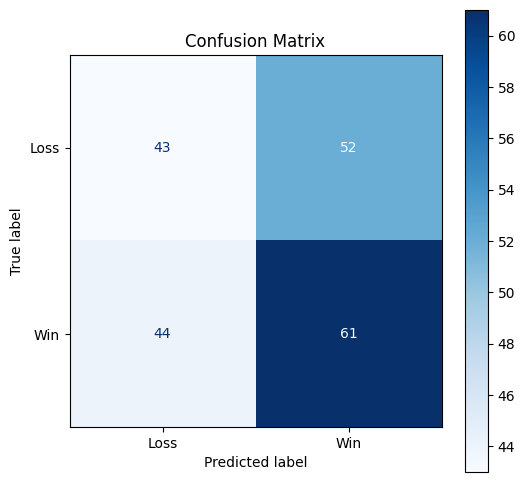


--- ROC Curve (AUC = 0.5013) ---


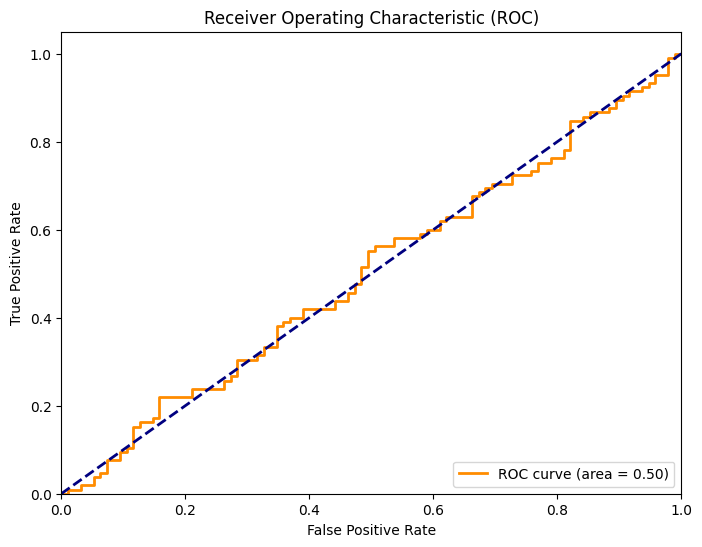


--- Classification Report ---
              precision    recall  f1-score   support

        Loss       0.49      0.45      0.47        95
         Win       0.54      0.58      0.56       105

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay

# 1. Prepare Data for Evaluation
# Switch model to evaluation mode
model_reg.eval()

with torch.no_grad():
    # Get raw probabilities (y_scores) from the test set
    y_scores = model_reg(X_test_tensor)
    
    # Convert probabilities to binary predictions (0 or 1)
    y_pred = (y_scores >= 0.5).float()

    # Convert PyTorch tensors to NumPy arrays for use with sklearn
    y_true_np = y_test_tensor.numpy()
    y_scores_np = y_scores.numpy()
    y_pred_np = y_pred.numpy()

# 2. Generate and Plot Confusion Matrix
# The confusion matrix helps visualize correct vs incorrect predictions
cm = confusion_matrix(y_true_np, y_pred_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss', 'Win'])

print("--- Confusion Matrix ---")
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()

# 3. Generate and Plot ROC Curve
# The ROC curve illustrates the trade-off between TPR (Recall) and FPR
fpr, tpr, thresholds = roc_curve(y_true_np, y_scores_np)
roc_auc = auc(fpr, tpr)

print(f"\n--- ROC Curve (AUC = {roc_auc:.4f}) ---")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# 4. Generate Classification Report
# This calculates Precision, Recall, and F1-Score
print("\n--- Classification Report ---")
report = classification_report(y_true_np, y_pred_np, target_names=['Loss', 'Win'])
print(report)



Double-click <b>here</b> for the Hint.
<!-- 

#Change the name of variables as per your code
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools

# Visualize the confusion matrix
#Change the variable names as used in your code
y_pred_test_labels = (y_pred_test > 0.5).float()
cm = confusion_matrix(y_test, y_pred_test_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_test_labels, target_names=['Loss', 'Win']))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
-->


### Step 6: Model Saving and Loading  

#### Task 6: Save and load the trained model.  

This task demonstrates the techniques to persist a trained model using `torch.save` and reload it using `torch.load`. Evaluating the loaded model ensures that it retains its performance, making it practical for deployment in real-world applications.  

1. Saving the Model:
- Save the model's learned weights and biases using torch.save().( e.g. , torch.save(model.state_dict(), 'your_model_name.pth'))
- Saving only the state dictionary (model parameters) is preferred because it’s more flexible and efficient than saving the entire model object.

2. Loading the Model:
- Create a new model instance (e.g., `model = LogisticRegressionModel()`) and load the saved parameters. ( e.g. , `model.load_state_dict(torch.load('your_model_name.pth'))`)`.

3. Evaluating the Loaded Model:
   - After loading, set the model to evaluation mode by calling `model.eval()
   - After loading the model, evaluate it again on the test dataset to make sure it performs similarly to when it was first trained..Now evaluate it on the test data.
   - Use `torch.no_grad()` to ensure that no gradients are computed.

#### Exercise 6:  

Write code to save the trained model and reload it. Ensure the loaded model performs consistently by evaluating it on the test dataset.  


In [8]:
import torch

# Define the filename for the saved model
model_filename = 'logistic_regression_model.pth'

# 1. Save the Model
# We save the state_dict (learned weights & biases) rather than the entire object.
# This is preferred for flexibility and efficiency.
torch.save(model_reg.state_dict(), model_filename)
print(f"Model parameters saved to '{model_filename}'")

# 2. Load the Model
# First, create a NEW instance of the model with the same architecture (input_dim)
loaded_model = LogisticRegressionModel(input_dim)

# Load the saved parameters into the new instance
loaded_model.load_state_dict(torch.load(model_filename))
print("Model parameters loaded successfully into new instance.")

# 3. Evaluate the Loaded Model
# Set the loaded model to evaluation mode
loaded_model.eval()

with torch.no_grad():
    # Pass the test data through the loaded model
    # We use X_test_tensor and y_test_tensor from Step 1
    test_outputs = loaded_model(X_test_tensor)
    
    # Convert probabilities to binary predictions
    test_predicted = (test_outputs >= 0.5).float()
    
    # Calculate accuracy
    accuracy = (test_predicted == y_test_tensor.unsqueeze(1)).float().mean()

# 4. Print Verification
print(f"\nLoaded Model Test Accuracy: {accuracy.item():.4f}")




Model parameters saved to 'logistic_regression_model.pth'
Model parameters loaded successfully into new instance.

Loaded Model Test Accuracy: 0.5200


### Step 7: Hyperparameter Tuning  

#### Task 7: Perform hyperparameter tuning to find the best learning rate.  

By testing different learning rates, you will identify the optimal rate that provides the best test accuracy. This fine-tuning is crucial for enhancing model performance . 
1. Define Learning Rates:
   - Choose these learning rates to test ,[0.01, 0.05, 0.1]

2. Reinitialize the Model for Each Learning Rate:
  - For each learning rate, you’ll need to reinitialize the model and optimizer e.g.(`torch.optim.SGD(model.parameters(), lr=lr)`).
   - Each new learning rate requires reinitializing the model since the optimizer and its parameters are linked to the learning rate.

3. Train the Model for Each Learning Rate:
  - Train the model for a fixed number of epochs (e.g., 50 or 100 epochs) for each learning rate, and compute the accuracy on the test set.
  - Track the test accuracy for each learning rate and identify which one yields the best performance.

4. Evaluate and Compare:
  - After training with each learning rate, compare the test accuracy for each configuration.
   - Report the learning rate that gives the highest test accuracy

#### Exercise 7:  

Perform hyperparameter tuning to find the best learning rate. Retrain the model for each learning rate and evaluate its performance to identify the optimal rate.  


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define Learning Rates to Test
learning_rates = [0.01, 0.05, 0.1]

# Dictionary to store the test accuracy for each learning rate
results = {}

print("Starting Hyperparameter Tuning...")

# 2. Iterate Through Each Learning Rate
for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")
    
    # Reinitialize the Model for each run to ensure a fair comparison
    # We must create a fresh instance so we don't start with pre-trained weights
    model_tune = LogisticRegressionModel(input_dim)
    
    # Define Loss Function
    criterion = nn.BCELoss()
    
    # Initialize Optimizer with the current learning rate
    optimizer_tune = optim.SGD(model_tune.parameters(), lr=lr)
    
    # 3. Train the Model (Fixed number of epochs)
    # The instructions suggest 50 or 100 epochs. We'll use 100.
    num_epochs_tuning = 100
    
    model_tune.train()
    for epoch in range(num_epochs_tuning):
        optimizer_tune.zero_grad()
        outputs = model_tune(X_train_tensor)
        loss = criterion(outputs, y_train_tensor.unsqueeze(1))
        loss.backward()
        optimizer_tune.step()
        
    # 4. Evaluate on Test Set
    model_tune.eval()
    with torch.no_grad():
        test_outputs = model_tune(X_test_tensor)
        test_predicted = (test_outputs >= 0.5).float()
        test_accuracy = (test_predicted == y_test_tensor.unsqueeze(1)).float().mean()
        
    # Store the result
    acc_value = test_accuracy.item()
    results[lr] = acc_value
    print(f"Test Accuracy for lr={lr}: {acc_value:.4f}")

# 5. Identify and Report the Best Learning Rate
# Find the key (learning rate) with the maximum value (accuracy)
best_lr = max(results, key=results.get)
best_acc = results[best_lr]

print("-" * 30)
print(f"Hyperparameter Tuning Complete.")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Test Accuracy: {best_acc:.4f}")
print("-" * 30)



Starting Hyperparameter Tuning...

Testing Learning Rate: 0.01
Test Accuracy for lr=0.01: 0.5200

Testing Learning Rate: 0.05
Test Accuracy for lr=0.05: 0.4450

Testing Learning Rate: 0.1
Test Accuracy for lr=0.1: 0.5150
------------------------------
Hyperparameter Tuning Complete.
Best Learning Rate: 0.01
Best Test Accuracy: 0.5200
------------------------------


### Step 8: Feature Importance  

#### Task 8: Evaluate feature importance to understand the impact of each feature on the prediction.  

The code to evaluate feature importance to understand the impact of each feature on the prediction.

 1.Extracting Model Weights:
  - The weights of the logistic regression model represent the importance of each feature in making predictions. These weights are stored in the model's linear layer (`model.linear.weight`).
 - You can extract the weights using `model.linear.weight.data.numpy()` and flatten the resulting tensor to get a 1D array of feature importances.

2.Creating a DataFrame:
 - Create a pandas DataFrame with two columns: one for the feature names and the other for their corresponding importance values (i.e., the learned weights).
 - Ensure the features are aligned with their names in your dataset (e.g., `X_train.columns).

3. Sorting and Plotting Feature Importance:
  - Sort the features based on the absolute value of their importance (weights) to identify the most impactful features.
  - Use a bar plot (via `matplotlib`) to visualize the sorted feature importances, with the feature names on the y-axis and importance values on the x-axis.

4. Interpreting the Results:
  - Larger absolute weights indicate more influential features. Positive weights suggest a positive correlation with the outcome (likely to predict the positive class), while negative weights suggest the opposite.

#### Exercise 8:  

Evaluate feature importance by extracting the weights of the linear layer and creating a DataFrame to display the importance of each feature. Visualize the feature importance using a bar plot.  


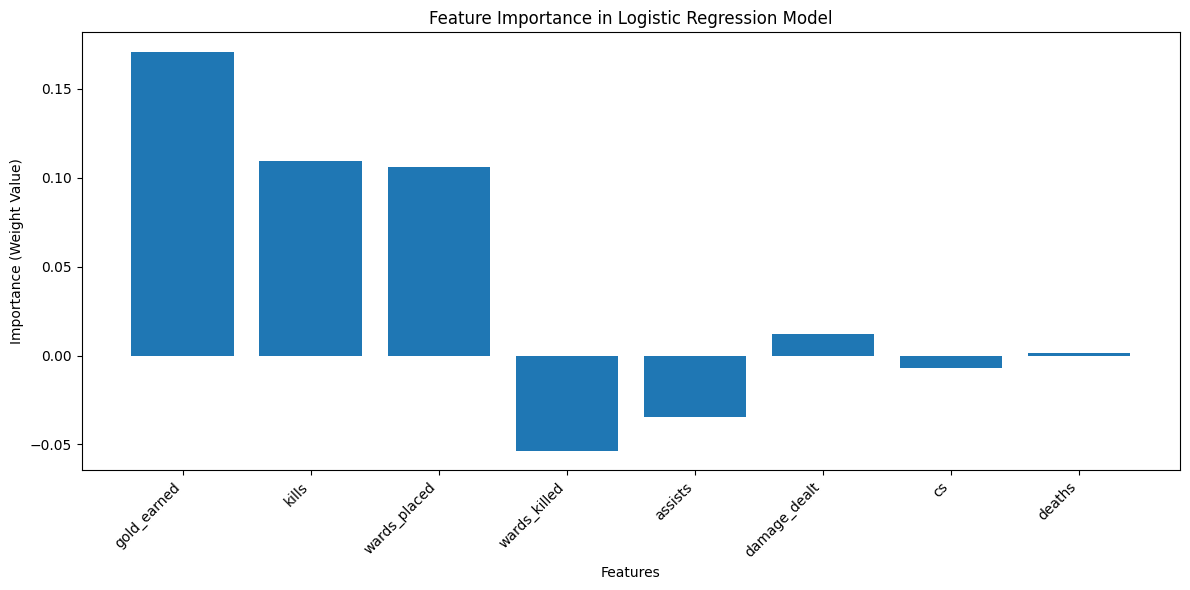


Top 5 Most Influential Features:
        Feature  Importance
3   gold_earned    0.170645
0         kills    0.109404
5  wards_placed    0.106238
6  wards_killed   -0.053470
2       assists   -0.034813


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract Model Weights
# The weights are stored in the linear layer of the model.
# We detach them from the computation graph, convert to numpy, and flatten to 1D.
# Note: Ensure you are using your trained model instance (e.g., 'model' or 'model_reg')
weights = model.linear.weight.data.numpy().flatten()

# 2. Get Feature Names
# We retrieve the column names from the original features DataFrame (X) created in Step 1.
feature_names = X.columns

# 3. Create a DataFrame for Feature Importance
# We map the feature names to their corresponding learned weights.
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': weights
})

# 4. Sort by Absolute Importance
# We are interested in the magnitude of the impact, whether positive or negative.
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

# 5. Visualize Feature Importance
plt.figure(figsize=(12, 6))
# We plot the raw importance values to see direction (positive/negative impact)
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance (Weight Value)')
plt.title('Feature Importance in Logistic Regression Model')
plt.tight_layout()
plt.show()

# Optional: Display the top 5 most important features
print("\nTop 5 Most Influential Features:")
print(feature_importance[['Feature', 'Importance']].head(5))




Double-click <b>here</b> for the Hint
<!-- 
#Use the following code to extract the weight and create dataframe
#Change the name of variables per your code

Extract the weights of the linear layer:
weights = model.linear.weight.data.numpy().flatten()
features = X.columns
Create a DataFrame for feature importance:
feature_importance = pd.DataFrame({'Feature': features, 'Importance': weights})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)
Plot feature importance plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()
-->


#### Conclusion:  

Congratulations on completing the project! In this final project, you built a logistic regression model to predict the outcomes of League of Legends matches based on various in-game statistics. This comprehensive project involved several key steps, including data loading and preprocessing, model implementation, training, optimization, evaluation, visualization, model saving and loading, hyperparameter tuning, and feature importance analysis. This project provided hands-on experience with the complete workflow of developing a machine learning model for binary classification tasks using PyTorch.

© Copyright IBM Corporation. All rights reserved.
